In [1]:
#Basics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#Model import
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

#Metrics and configurations
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.model_selection import StratifiedGroupKFold, GridSearchCV
from collections import Counter
from sklearn.model_selection import ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
import optuna
from sklearn.feature_selection import SelectKBest, f_classif
import joblib


# Datasets

In [2]:
df_PLC_CECT = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/feature_extraction_data_PLC_CECT.xlsx")
df_UCSF_RMaC = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/feature_extraction_data_UCSF_RMaC.xlsx")
df_VinDr = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/feature_extraction_data_VinDr.xlsx")
df_WAW_TACE = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/waw_tace_feature_extraction_data.xlsx")

# Annotations

In [4]:
df_PLC_CECT_labels = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/Annotations/annotations_PLC_CECT_updated.xlsx")
df_VinDr_labels = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/Annotations/VinDr_annotations.xlsx")
df_UCSF_RMaC_labels = pd.read_excel("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/Annotations/ucsf_rmac_annotations.xlsx")
df_WAW_TACE_labels = pd.read_csv("Z:/CTphaseClassification/Project_work/Pipeline/ProjectA/CTPhaseClassifier/Annotations/waw_tace_annotations.csv", sep = ";")

# Merge data

## PLC CECT

In [6]:
#PLC CECT merge
num_df_PLC_CECT = df_PLC_CECT.copy()
labels_df_PLC_CECT = df_PLC_CECT_labels.copy()

num_df_PLC_CECT["match_key"] = num_df_PLC_CECT["case"].str.replace("_converted", "", regex=False)
labels_df_PLC_CECT["match_key"] = labels_df_PLC_CECT["Name"].str.replace(".nii.gz", "", regex=False)

merged_df_PLC_CECT = num_df_PLC_CECT.merge(labels_df_PLC_CECT[["match_key", "Phase"]],on="match_key",how="inner")

#Merged dataset
merged_df_PLC_CECT = merged_df_PLC_CECT.drop(columns=["match_key"])

## UCSF RMaC

In [7]:
#UCSF RMaC merge
num_df_UCSF_RMaC = df_UCSF_RMaC.copy()
labels_df_UCSF_RMaC = df_UCSF_RMaC_labels.copy()

num_df_UCSF_RMaC["Patient"] = num_df_UCSF_RMaC["case"].str.extract(r"^([^_]+)")
num_df_UCSF_RMaC["Old_labels"] = num_df_UCSF_RMaC["case"].str.extract(r"^[^_]+_([^_]+)_")
merged_df_UCSF_RMaC = num_df_UCSF_RMaC.merge(labels_df_UCSF_RMaC[["PID", "Old_labels", "Phase"]],left_on=["Patient", "Old_labels"],right_on=["PID", "Old_labels"], how="inner")

#Merged dataset
merged_df_UCSF_RMaC = merged_df_UCSF_RMaC.drop(columns=["PID"])

## VinDr Multiphase

In [8]:
#VinDr Multiphase Merge
num_df_VinDr = df_VinDr.copy()
labels_df_VinDr = df_VinDr_labels.copy()
num_df_VinDr["match_key"] = num_df_VinDr["case"].str.extract(r"_(P\d+_S\d+)_")
merged_df_VinDr = num_df_VinDr.merge(labels_df_VinDr[["SeriesInstanceUID", "Phase"]],left_on="match_key",right_on="SeriesInstanceUID",how="inner")

#Merged dataset
merged_df_VinDr = merged_df_VinDr.drop(columns=["SeriesInstanceUID", "match_key"])



## WAW TACE

In [9]:
#WAW TACE merge
num_df_WAW_TACE = df_WAW_TACE.copy()
labels_df_WAW_TACE = df_WAW_TACE_labels.copy()

num_df_WAW_TACE["match_key"] = num_df_WAW_TACE["case"].str.replace(r"^(HCC_\d+_PRE)_", "", regex=True)
labels_df_WAW_TACE["match_key"] = labels_df_WAW_TACE["SeriesInstanceUID"].str.replace(".nii.gz", "", regex=False)

merged_df_WAW_TACE = num_df_WAW_TACE.merge(labels_df_WAW_TACE[["match_key", "Phase"]],on="match_key",how="inner")

#Merged dataset
merged_df_WAW_TACE = merged_df_WAW_TACE.drop(columns=["match_key"])

#print(merged_df_WAW_TACE[["case", "Phase"]].head(20))

# Check amount of data

In [10]:
#Merge all datasets
df_all = pd.concat([merged_df_PLC_CECT,merged_df_UCSF_RMaC,merged_df_VinDr,merged_df_WAW_TACE], ignore_index=True)

print(f"Number of features {len(df_all.drop(columns=['dataset', 'Phase', 'Patient', 'Old_labels', 'case']).columns)}")
print(f"Total number of scans: {len(df_all)} ")

#Table distributions
print("Table distributions")
phase_order = ["NP", "AP", "VP", "DP"]
df_all["Phase"] = pd.Categorical(df_all["Phase"], categories=phase_order, ordered=True)
phase_dist = df_all.groupby(["Phase", "dataset"]).size().unstack(fill_value=0)
phase_dist = phase_dist.reindex(phase_order)
print(phase_dist)

Number of features 328
Total number of scans: 4525 
Table distributions
dataset  PLC_CECT  UCSF-RMaC  VinDr_Multiphase  WAW_TACE
Phase                                                   
NP            361        824               150        99
AP            361        364               155       109
VP            361        624               156        96
DP            361        488                16         0


# Check plot distributions

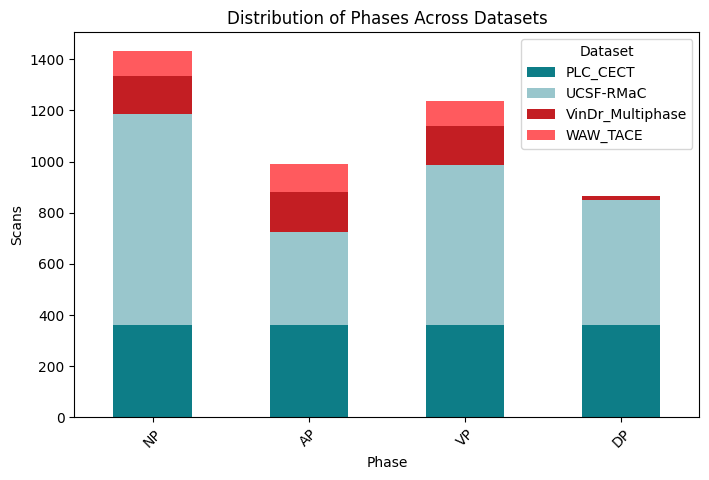

In [11]:
#Plot distribution
colors = ["#0d7d87", "#99c6cc", "#c31e23", "#ff5a5e"]
phase_dist.plot(kind="bar", stacked=True, color=colors, figsize=(10, 5))

plt.xlabel("Phase")
plt.ylabel("Scans")
plt.title("Distribution of Phases Across Datasets")
plt.xticks(rotation=45)
plt.subplots_adjust(right=0.75)
plt.legend(title="Dataset", loc="upper right")
plt.savefig("phase_distribution.png", dpi=300)
plt.show()

# Divide data

In [12]:
#Label datasets
merged_df_UCSF_RMaC["dataset"] = "UCSF_RMaC"
merged_df_VinDr["dataset"] = "VinDr_Multiphase"
merged_df_WAW_TACE["dataset"] = "WAW_TACE"
merged_df_PLC_CECT["dataset"] = "PLC_CECT"

#Create patient IDs
merged_df_UCSF_RMaC["patient_id"] = merged_df_UCSF_RMaC["case"].str.extract(r"^([^_]+)")
merged_df_VinDr["patient_id"] = merged_df_VinDr["case"].str.extract(r"^(P\d+)")
merged_df_WAW_TACE["patient_id"] = merged_df_WAW_TACE["case"].str.extract(r"^(HCC_\d+_PRE)")
merged_df_PLC_CECT["patient_id"] = (merged_df_PLC_CECT["case"].str.extract(r"^([^_]+)").astype(str) + "_PLC")

In [13]:
#Internal data
df_internal = pd.concat([merged_df_UCSF_RMaC, merged_df_VinDr, merged_df_WAW_TACE],ignore_index=True)
#External data =VinDr Multiphase
df_external = merged_df_PLC_CECT

In [14]:
#Create group ID
df_internal["group_id"] = df_internal["dataset"] + "_" + df_internal["patient_id"].astype(str)

## Check data information

In [15]:
print("---------------------Overall patient information---------------------")
print(df_internal[["case", "dataset", "patient_id", "group_id", "Phase"]].sample(10))
print("---------------------Overall phase distribution---------------------")
print(df_internal["Phase"].value_counts())
print("---------------------Phase distribution across datasets---------------------")
print(df_internal.groupby("dataset")["Phase"].value_counts())
print("----------------------------------------------------------------------------")

print("Number of unique groups:", df_internal["group_id"].nunique())

---------------------Overall patient information---------------------
                             case           dataset  patient_id  \
468   DQ50zy8lCp_arterial_clipped         UCSF_RMaC  DQ50zy8lCp   
2697       P0241_P0241_S1_clipped  VinDr_Multiphase       P0241   
721   Kg8HB3cqqW_arterial_clipped         UCSF_RMaC  Kg8HB3cqqW   
1972    rdKMacoScX_noncon_clipped         UCSF_RMaC  rdKMacoScX   
668      IjFflm1TPw_delay_clipped         UCSF_RMaC  IjFflm1TPw   
1745    l7zTOfZuZ0_noncon_clipped         UCSF_RMaC  l7zTOfZuZ0   
1568    gHX2T4WFWt_noncon_clipped         UCSF_RMaC  gHX2T4WFWt   
839    N0ntKhL5k9_portven_clipped         UCSF_RMaC  N0ntKhL5k9   
1363    aWHWTo1Rny_noncon_clipped         UCSF_RMaC  aWHWTo1Rny   
1013   RclUDEPCYc_portven_clipped         UCSF_RMaC  RclUDEPCYc   

                    group_id Phase  
468     UCSF_RMaC_DQ50zy8lCp    AP  
2697  VinDr_Multiphase_P0241    NP  
721     UCSF_RMaC_Kg8HB3cqqW    AP  
1972    UCSF_RMaC_rdKMacoScX    NP  
668    

In [16]:
print("Mising values (NaN):")
print(df_internal[["patient_id", "group_id", "Phase"]].isna().sum())

Mising values (NaN):
patient_id    0
group_id      0
Phase         0
dtype: int64


## Remove datapoints where all values are -9999

In [17]:
#Internal
num_cols = df_internal.select_dtypes(include="number").columns

print("Före:", df_internal.shape)

df_internal = df_internal.loc[~(df_internal[num_cols] == -9999).all(axis=1)].copy()

print("Efter:", df_internal.shape)

mask = (df_internal[num_cols] == -9999).all(axis=1)
print("Kvarvarande rader där alla numeriska kolumner = -9999:", mask.sum())

Före: (3081, 335)
Efter: (3077, 335)
Kvarvarande rader där alla numeriska kolumner = -9999: 0


In [18]:
#External
num_cols = df_external.select_dtypes(include="number").columns

print("Före:", df_external.shape)

df_external = df_external.loc[~(df_external[num_cols] == -9999).all(axis=1)].copy()

print("Efter:", df_external.shape)

mask = (df_external[num_cols] == -9999).all(axis=1)
print("Kvarvarande rader där alla numeriska kolumner = -9999:", mask.sum())

#Number of rows deleted: 696

Före: (1444, 332)
Efter: (752, 332)
Kvarvarande rader där alla numeriska kolumner = -9999: 0


# Distribution after removing -9999 data

Number of features 330
Total number of scans: 3829 
Table distributions
dataset  PLC_CECT  UCSF_RMaC  VinDr_Multiphase  WAW_TACE
Phase                                                   
NP            188        824               149        99
AP            188        364               154       109
VP            188        624               154        96
DP            188        488                16         0
Total number of patients: 823


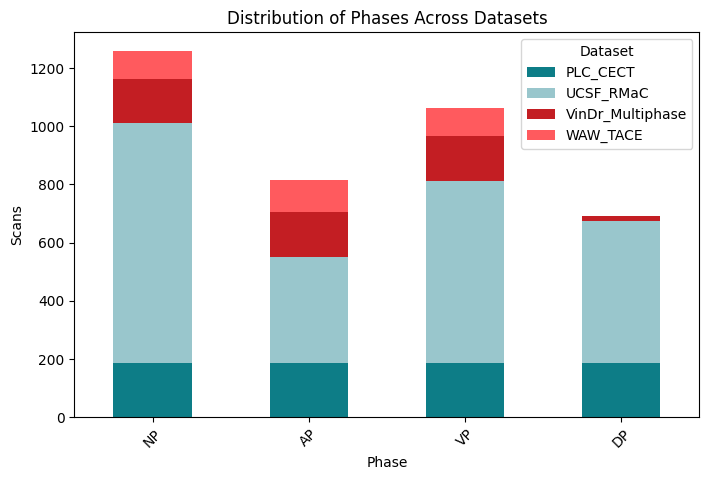

In [19]:
#Information after removal
df_all_new = pd.concat([df_internal, df_external], ignore_index=True)
print(f"Number of features {len(df_all_new.drop(columns=['dataset', 'Phase', 'Patient', 'Old_labels', 'case']).columns)}")
print(f"Total number of scans: {len(df_all_new)} ")
 
#Table distributions
print("Table distributions")
phase_order = ["NP", "AP", "VP", "DP"]
df_all_new["Phase"] = pd.Categorical(df_all_new["Phase"], categories=phase_order, ordered=True)
phase_dist = df_all_new.groupby(["Phase", "dataset"]).size().unstack(fill_value=0)
phase_dist = phase_dist.reindex(phase_order)
print(phase_dist)
print(f"Total number of patients: {df_all_new['Patient'].nunique()}")
#Plot distribution
colors = ["#0d7d87", "#99c6cc", "#c31e23", "#ff5a5e"]
phase_dist.plot(kind="bar", stacked=True, color=colors, figsize=(10, 5))

plt.xlabel("Phase")
plt.ylabel("Scans")
plt.title("Distribution of Phases Across Datasets")
plt.xticks(rotation=45)
plt.subplots_adjust(right=0.75)
plt.legend(title="Dataset", loc="upper right")
plt.savefig("phase_distribution_after_removing.png", dpi=300)
plt.show()

## Another format of the table above

Number of features 330
Total number of scans: 3829 
Table distributions
dataset  PLC_CECT  UCSF_RMaC  VinDr_Multiphase  WAW_TACE
Phase                                                   
NP            188        824               149        99
AP            188        364               154       109
VP            188        624               154        96
DP            188        488                16         0
Total number of patients: 823


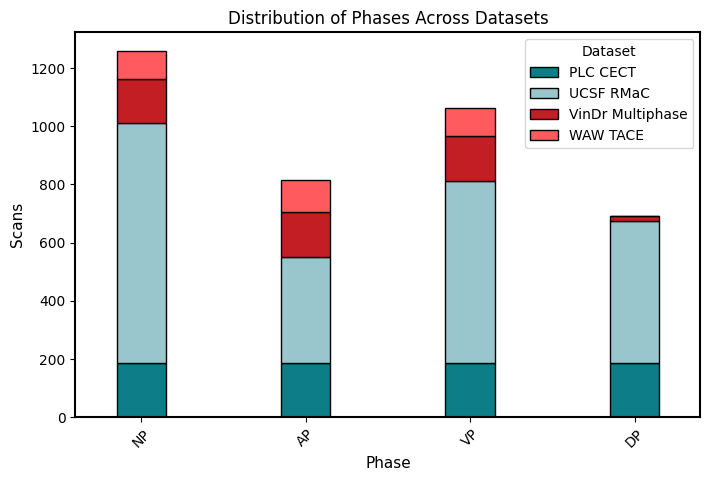

In [20]:
#Information after removal
df_all_new = pd.concat([df_internal, df_external], ignore_index=True)
print(f"Number of features {len(df_all_new.drop(columns=['dataset', 'Phase', 'Patient', 'Old_labels', 'case']).columns)}")
print(f"Total number of scans: {len(df_all_new)} ")
 
#Table distributions
print("Table distributions")
phase_order = ["NP", "AP", "VP", "DP"]
df_all_new["Phase"] = pd.Categorical(df_all_new["Phase"], categories=phase_order, ordered=True)
phase_dist = df_all_new.groupby(["Phase", "dataset"]).size().unstack(fill_value=0)
phase_dist = phase_dist.reindex(phase_order)
print(phase_dist)
print(f"Total number of patients: {df_all_new['Patient'].nunique()}")

#Samma stilinställningar som tidigare
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Clear Sans", "DejaVu Sans", "Arial"]
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

#Plot distribution
colors = ["#0d7d87", "#99c6cc", "#c31e23", "#ff5a5e"]
ax = phase_dist.plot(kind="bar",stacked=True,color=colors,figsize=(10, 5),edgecolor="black",linewidth=1.0,width=0.3)
plt.xlabel("Phase")
plt.ylabel("Scans")
plt.title("Distribution of Phases Across Datasets")
plt.xticks(rotation=45)
plt.subplots_adjust(right=0.75)
handles, labels = ax.get_legend_handles_labels()
labels = [label.replace("_", " ").replace("Cect", "CECT").replace("Ucsf", "UCSF").replace("Rmac", "RMaC").replace("Vindr", "VinDr").replace("Waw", "WAW").replace("Tace", "TACE") for label in labels]
plt.legend(handles, labels, title="Dataset", loc="upper right")
plt.savefig("phase_distribution_after_removing.png", dpi=300)
plt.show()

# Model development

## Features to use

In [21]:
final_features = [
    "Mean_aorta",
    "Mean_kidneys",
    "Mean_liver",
    "Mean_portal_vein_and_splenic_vein",
    "Mean_spleen",
    "Mean_urinary_bladder",
    "Standard Deviation_aorta",
    "Standard Deviation_kidneys",
    "Standard Deviation_liver",
    "Standard Deviation_portal_vein_and_splenic_vein",
    "Standard Deviation_spleen",
    "Standard Deviation_urinary_bladder",
    "10th Percentile_aorta",
    "10th Percentile_kidneys",
    "10th Percentile_liver",
    "10th Percentile_portal_vein_and_splenic_vein",
    "10th Percentile_spleen",
    "10th Percentile_urinary_bladder",
    "50th Percentile_aorta",
    "50th Percentile_kidneys",
    "50th Percentile_liver",
    "50th Percentile_portal_vein_and_splenic_vein",
    "50th Percentile_spleen",
    "50th Percentile_urinary_bladder",
    "90th Percentile_aorta",
    "90th Percentile_kidneys",
    "90th Percentile_liver",
    "90th Percentile_portal_vein_and_splenic_vein",
    "90th Percentile_spleen",
    "90th Percentile_urinary_bladder",
    "Skewness_spleen",
    "Kurtosis_spleen",
    "Entropy_spleen",
    "Uniformity_spleen",
    "Mean_diff_aorta_portal_vein_and_splenic_vein",
    "Median_diff_aorta_liver",
    "Median_diff_kidneys_portal_vein_and_splenic_vein",
    "Median_diff_aorta_portal_vein_and_splenic_vein",
    "Mean_diff_liver_portal_vein_and_splenic_vein",
    "Median_diff_liver_portal_vein_and_splenic_vein",
    "Skewness_liver",
    "Kurtosis_liver",
    "Entropy_liver",
    "Uniformity_liver",
    "GLCM_Contrast_liver",
    "GLCM_Correlation_liver",
    "GLCM_JointEntropy_liver",
    "InterquartileRange (IQR)_liver",
    "Variance_liver",
    "Kurtosis_kidneys",
    "Median_diff_aorta_kidneys",
    "Skewness_kidneys",
    "Mean_diff_aorta_liver",
    "10th Percentile_diff_aorta_kidneys",
    "50th Percentile_diff_aorta_kidneys",
    "GLSZM_ZoneVariance_urinary_bladder",
    "Entropy_portal_vein_and_splenic_vein",
    "Uniformity_portal_vein_and_splenic_vein",
    "Mean_diff_liver_spleen",
    "Mean_diff_kidneys_portal_vein_and_splenic_vein",
]

## Build datasets

In [22]:
X_internal = df_internal[final_features].copy()
y_internal = df_internal["Phase"].copy()
groups_internal = df_internal["group_id"].copy()

X_external = df_external[final_features].copy()
y_external = df_external["Phase"].copy()

In [23]:
print("Internal class distribution:")
print(y_internal.value_counts())

print("\nExternal class distribution:")
print(y_external.value_counts())

Internal class distribution:
Phase
NP    1072
VP     874
AP     627
DP     504
Name: count, dtype: int64

External class distribution:
Phase
AP    188
VP    188
DP    188
NP    188
Name: count, dtype: int64


In [24]:
#Label encoder
label_encoder = LabelEncoder()
y_internal_enc = label_encoder.fit_transform(y_internal)
y_external_enc = label_encoder.transform(y_external)

class_names = label_encoder.classes_
print("Classes:", class_names)

Classes: ['AP' 'DP' 'NP' 'VP']


## Divide internal training and test

In [25]:
sgkf_inner = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

train_dev_idx, internal_test_idx = next(sgkf_inner.split(X_internal, y_internal_enc, groups_internal))

X_train_dev = X_internal.iloc[train_dev_idx].reset_index(drop=True)
y_train_dev = y_internal_enc[train_dev_idx]
groups_train_dev = groups_internal.iloc[train_dev_idx].reset_index(drop=True)

X_internal_test = X_internal.iloc[internal_test_idx].reset_index(drop=True)
y_internal_test = y_internal_enc[internal_test_idx]
groups_internal_test = groups_internal.iloc[internal_test_idx].reset_index(drop=True)

In [26]:
overlap = set(groups_train_dev).intersection(set(groups_internal_test))
print("Överlappande grupper mellan train_dev och internal_test:", len(overlap))

print("\nTotal intern fördelning:")
print(pd.Series(label_encoder.inverse_transform(y_internal_enc)).value_counts())

print("\nTrain_dev fördelning:")
print(pd.Series(label_encoder.inverse_transform(y_train_dev)).value_counts())

print("\nInternal test fördelning:")
print(pd.Series(label_encoder.inverse_transform(y_internal_test)).value_counts())

Överlappande grupper mellan train_dev och internal_test: 0

Total intern fördelning:
NP    1072
VP     874
AP     627
DP     504
Name: count, dtype: int64

Train_dev fördelning:
NP    964
VP    786
AP    564
DP    453
Name: count, dtype: int64

Internal test fördelning:
NP    108
VP     88
AP     63
DP     51
Name: count, dtype: int64


## Models

In [27]:
from sklearn.utils.class_weight import compute_sample_weight

models = {
    "Logistic Regression": Pipeline([("scaler", StandardScaler()),("model", LogisticRegression(max_iter=4000, solver="lbfgs", C=175, random_state=42, class_weight={0: 1.4, 1: 1.7, 2: 0.5, 3: 0.9})),]),
    "Random Forest": Pipeline([("model", RandomForestClassifier(n_estimators=400,max_depth=50,min_samples_leaf=3,min_samples_split=10,max_features="sqrt",random_state=42,n_jobs=-1, class_weight={0: 1.2, 1: 1.8, 2: 0.5, 3: 1.9}))]),
    "SVM": Pipeline([("scaler", StandardScaler()),("model", SVC(kernel="rbf",C=1015,gamma="scale",random_state=42, class_weight={0: 1.2, 1: 1.8, 2: 0.5, 3: 1.9}))]),
    "XGBoost": Pipeline([("model", XGBClassifier(n_estimators=800,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8,eval_metric="mlogloss",random_state=42))]),
}

#Encoder
#print(label_encoder.classes_)
#print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))
#{'AP': np.int64(0), 'DP': np.int64(1), 'NP': np.int64(2), 'VP': np.int64(3)}

# Bayesian optimization

In [ ]:
selected_feature_names = final_features
X_train_dev_selected = X_train_dev[final_features]

print("Selected features:")
for feat in selected_feature_names:
    print(f"  {feat}")


def make_objective(model_name, X_data, y_data, groups_data):
    def objective(trial):
        class_weights = {
            0: trial.suggest_float("w0", 0.2, 3.0),
            1: trial.suggest_float("w1", 0.2, 3.0),
            2: trial.suggest_float("w2", 0.2, 2.0),
            3: trial.suggest_float("w3", 0.2, 3.0),
        }

        if model_name == "LogisticRegression":
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", LogisticRegression(
                    max_iter=trial.suggest_int("lr_max_iter", 4000, 10000, step=2000),
                    solver="lbfgs",
                    C=trial.suggest_float("lr_C", 1e-3, 100, log=True),
                    class_weight=class_weights,
                    random_state=42
                ))
            ])

        elif model_name == "RandomForest":
            pipeline = Pipeline([
                ("model", RandomForestClassifier(
                    n_estimators=trial.suggest_int("rf_n_estimators", 100, 1000, step=100),
                    max_depth=trial.suggest_int("rf_max_depth", 3, 50),
                    min_samples_split=trial.suggest_int("rf_min_samples_split", 2, 20),
                    min_samples_leaf=trial.suggest_int("rf_min_samples_leaf", 1, 10),
                    max_features=trial.suggest_categorical("rf_max_features", ["sqrt", "log2", None]),
                    class_weight=class_weights,
                    random_state=42,
                    n_jobs=-1
                ))
            ])

        elif model_name == "SVC":
            pipeline = Pipeline([
                ("scaler", StandardScaler()),
                ("model", SVC(
                    kernel="rbf",
                    C=trial.suggest_float("svc_C", 1e-2, 100, log=True),
                    gamma=trial.suggest_categorical("svc_gamma", ["scale", "auto"]),
                    class_weight=class_weights,
                    random_state=42
                ))
            ])

        elif model_name == "XGBoost":
            pipeline = Pipeline([
                ("model", XGBClassifier(
                    n_estimators=trial.suggest_int("xgb_n_estimators", 100, 1000, step=100),
                    max_depth=trial.suggest_int("xgb_max_depth", 3, 10),
                    learning_rate=trial.suggest_float("xgb_learning_rate", 1e-3, 0.3, log=True),
                    subsample=trial.suggest_float("xgb_subsample", 0.5, 1.0),
                    colsample_bytree=trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0),
                    reg_alpha=trial.suggest_float("xgb_reg_alpha", 1e-8, 10.0, log=True),
                    reg_lambda=trial.suggest_float("xgb_reg_lambda", 1e-8, 10.0, log=True),
                    eval_metric="mlogloss",
                    random_state=42
                ))
            ])

        else:
            raise ValueError(f"Unknown model_name: {model_name}")

        sgkf = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
        f1_scores = []

        for train_idx, val_idx in sgkf.split(X_data, y_data, groups_data):
            X_train = X_data.iloc[train_idx]
            X_val = X_data.iloc[val_idx]
            y_train = y_data[train_idx]
            y_val = y_data[val_idx]

            if model_name == "XGBoost":
                sample_weights = np.array([class_weights[y_i] for y_i in y_train])
                pipeline.fit(X_train, y_train, model__sample_weight=sample_weights)
            else:
                pipeline.fit(X_train, y_train)

            y_pred = pipeline.predict(X_val)
            f1 = f1_score(y_val, y_pred, average="macro")
            f1_scores.append(f1)

        return np.mean(f1_scores)

    return objective


models_to_tune = ["LogisticRegression", "RandomForest", "SVC", "XGBoost"]

studies = {}
best_results = {}

for model_name in models_to_tune:
    print(f"\n===== Tuning {model_name} =====")

    study = optuna.create_study(
        direction="maximize",
        study_name=f"{model_name}_test_new_20260427_v1",
        storage="sqlite:///optuna_models.db",
        load_if_exists=True
    )

    objective = make_objective(
        model_name,
        X_train_dev_selected,
        y_train_dev,
        groups_train_dev
    )

    study.optimize(objective, n_trials=150)

    studies[model_name] = study
    best_results[model_name] = {
        "best_value": study.best_value,
        "best_params": study.best_params
    }

    print(f"Best F1-macro for {model_name}: {study.best_value:.4f}")
    print("Best parameters:")
    for param_name, param_value in study.best_params.items():
        print(f"  {param_name}: {param_value}")

print("\n===== FINAL SUMMARY =====")
for model_name, result in best_results.items():
    print(f"{model_name}:")
    print(f"  Best F1-macro: {result['best_value']:.4f}")
    print(f"  Best params: {result['best_params']}")

#Remove database before each run: Remove-Item .\optuna_models.db
#OPEN LIVE by running this in the terminal: optuna-dashboard sqlite:///optuna_models.db
#https://optuna-dashboard.readthedocs.io/en/latest/getting-started.html 

# Final test

In [ ]:
#BUILD FINAL MODEL FROM OPTUNA BEST PARAMS
def build_model_from_best_params(model_name, best_params):
    class_weights = {0: best_params["w0"],1: best_params["w1"],2: best_params["w2"],3: best_params["w3"],}

    if model_name == "LogisticRegression":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=best_params["lr_max_iter"],
                solver="lbfgs",
                C=best_params["lr_C"],
                class_weight=class_weights,
                random_state=42
            ))
        ])

    elif model_name == "RandomForest":
        model = Pipeline([
            ("model", RandomForestClassifier(
                n_estimators=best_params["rf_n_estimators"],
                max_depth=best_params["rf_max_depth"],
                min_samples_split=best_params["rf_min_samples_split"],
                min_samples_leaf=best_params["rf_min_samples_leaf"],
                max_features=best_params["rf_max_features"],
                class_weight=class_weights,
                random_state=42,
                n_jobs=-1
            ))
        ])

    elif model_name == "SVC":
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(
                kernel="rbf",
                C=best_params["svc_C"],
                probability=True,
                gamma=best_params["svc_gamma"],
                class_weight=class_weights,
                random_state=42
            ))
        ])

    elif model_name == "XGBoost":
        model = Pipeline([
            ("model", XGBClassifier(
                n_estimators=best_params["xgb_n_estimators"],
                max_depth=best_params["xgb_max_depth"],
                learning_rate=best_params["xgb_learning_rate"],
                subsample=best_params["xgb_subsample"],
                colsample_bytree=best_params["xgb_colsample_bytree"],
                reg_alpha=best_params["xgb_reg_alpha"],
                reg_lambda=best_params["xgb_reg_lambda"],
                eval_metric="mlogloss",
                random_state=42
            ))
        ])

    return model, class_weights

#CHOOSE WHICH MODEL TO USE
#If we want to specify the best model manually:
best_model_name = "XGBoost"

#If we wantto automatically select the best model, use this:
# best_model_name = max(best_results, key=lambda m: best_results[m]["best_value"])

best_params = best_results[best_model_name]["best_params"]

print("\n===== FINAL MODEL =====")
print("Model:", best_model_name)
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

#BUILD FINAL PIPELINE
best_model, class_weights = build_model_from_best_params(best_model_name, best_params)

#USE SAME FEATURES EVERYWHERE
selected_feature_names = final_features

X_train_dev_final = X_train_dev[selected_feature_names]
X_internal_test_final = X_internal_test[selected_feature_names]
X_external_final = X_external[selected_feature_names]

#TRAIN ON WHOLE 90% INTERNAL TRAIN
if best_model_name == "XGBoost":
    sample_weights = np.array([class_weights[y_i] for y_i in y_train_dev])
    best_model.fit(X_train_dev_final, y_train_dev, model__sample_weight=sample_weights)
else:
    best_model.fit(X_train_dev_final, y_train_dev)


#SAVE MODEL
joblib.dump(best_model, "final_model_new.pkl")
joblib.dump(selected_feature_names, "features_new.pkl")
joblib.dump(label_encoder, "label_encoder_new.pkl")


#TEST ON INTERNAL 10%
y_pred_internal = best_model.predict(X_internal_test_final)

print("\n===== INTERNAL TEST =====")
print("Accuracy:", accuracy_score(y_internal_test, y_pred_internal))
print("F1-score (weighted):", f1_score(y_internal_test, y_pred_internal, average="weighted"))
print("F1-score (macro):", f1_score(y_internal_test, y_pred_internal, average="macro"))
print(classification_report(y_internal_test, y_pred_internal, target_names=class_names))

#TEST ON EXTERNAL DATASET
y_pred_external = best_model.predict(X_external_final)

print("\n===== EXTERNAL TEST =====")
print("Accuracy:", accuracy_score(y_external_enc, y_pred_external))
print("F1-score (weighted):", f1_score(y_external_enc, y_pred_external, average="weighted"))
print("F1-score (macro):", f1_score(y_external_enc, y_pred_external, average="macro"))
print(classification_report(y_external_enc, y_pred_external, target_names=class_names))

## McNemar's test

In [ ]:
import numpy as np
import pandas as pd

from itertools import combinations
from scipy.stats import binomtest

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

selected_feature_names = final_features

X_train_dev_selected = X_train_dev[selected_feature_names].copy()
X_internal_test_selected = X_internal_test[selected_feature_names].copy()
X_external_selected = X_external[selected_feature_names].copy()

print("Training data:", X_train_dev_selected.shape)
print("Internal test:", X_internal_test_selected.shape)
print("External test:", X_external_selected.shape)

try:
    print("Label encoder classes:", list(label_encoder.classes_))
except Exception:
    print("Could not print label_encoder.classes_")


models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            C=99.2573,
            max_iter=6000,
            solver="lbfgs",
            class_weight={0: 2.9348, 1: 2.6565, 2: 0.6942, 3: 2.4923},
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=700,
            max_depth=26,
            min_samples_split=3,
            min_samples_leaf=2,
            max_features=None,
            class_weight={0: 2.4012, 1: 2.5584, 2: 1.4910, 3: 2.9103},
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=96.2294,
            gamma="scale",
            class_weight={0: 1.6015, 1: 2.5638, 2: 1.5796, 3: 2.5318},
            random_state=42
        ))
    ]),

    "XGBoost": Pipeline([
        ("model", XGBClassifier(
            n_estimators=1000,
            max_depth=9,
            learning_rate=0.0264,
            subsample=0.9742,
            colsample_bytree=0.5603,
            reg_alpha=1.5764e-8,
            reg_lambda=3.1434e-7,
            eval_metric="mlogloss",
            random_state=42
        ))
    ]),
}


internal_predictions = {}
external_predictions = {}

for model_name, model in models.items():
    print(f"Training {model_name}...")

    if model_name == "XGBoost":
        xgb_weights = {0: 1.2499, 1: 1.4626, 2: 0.4836, 3: 2.4202}
        sample_weights = np.array([xgb_weights[int(y)] for y in y_train_dev])
        model.fit(X_train_dev_selected, y_train_dev, model__sample_weight=sample_weights)
    else:
        model.fit(X_train_dev_selected, y_train_dev)

    internal_predictions[model_name] = model.predict(X_internal_test_selected)
    external_predictions[model_name] = model.predict(X_external_selected)


def run_mcnemar_tests(predictions, y_true, dataset_name):
    y_true = np.asarray(y_true)
    rows = []

    for model_a, model_b in combinations(predictions.keys(), 2):
        pred_a = np.asarray(predictions[model_a])
        pred_b = np.asarray(predictions[model_b])

        a_correct = pred_a == y_true
        b_correct = pred_b == y_true

        both_correct = int((a_correct & b_correct).sum())
        a_wrong_b_right = int((~a_correct & b_correct).sum())
        a_right_b_wrong = int((a_correct & ~b_correct).sum())
        both_wrong = int((~a_correct & ~b_correct).sum())

        discordant = a_wrong_b_right + a_right_b_wrong

        if discordant > 0:
            p_value = binomtest(
                min(a_wrong_b_right, a_right_b_wrong),n=discordant,p=0.5,alternative="two-sided").pvalue
        else:
            p_value = 1.0

        rows.append({
            "dataset": dataset_name,
            "model_a": model_a,
            "model_b": model_b,
            "both_correct": both_correct,
            "model_a_wrong_model_b_right": a_wrong_b_right,
            "model_a_right_model_b_wrong": a_right_b_wrong,
            "both_wrong": both_wrong,
            "discordant_pairs": discordant,
            "p_value": p_value,
            "significant_p_0_05": p_value < 0.05,
        })

    return pd.DataFrame(rows)


internal_mcnemar = run_mcnemar_tests(internal_predictions,y_internal_test,"Internal test set")
external_mcnemar = run_mcnemar_tests(external_predictions,y_external_enc,"Dataset B")
mcnemar_results = pd.concat([internal_mcnemar, external_mcnemar],ignore_index=True)
display(mcnemar_results)
mcnemar_results.to_csv("mcnemar_results_internal_datasetB.csv", index=False)
mcnemar_results.to_excel("mcnemar_results_internal_datasetB.xlsx", index=False)

print("Saved:")
print("mcnemar_results_internal_datasetB.csv")
print("mcnemar_results_internal_datasetB.xlsx")

### Internal and external confusion matrix

In [ ]:
desired_order = ["NP", "AP", "VP", "DP"]

label_map = {name: i for i, name in enumerate(class_names)}
ordered_labels = [label_map[name] for name in desired_order]


cm_internal = confusion_matrix(
    y_internal_test,
    y_pred_internal,
    labels=ordered_labels
)

plt.figure()
plt.imshow(cm_internal, cmap="Blues")
plt.title(f"Internal Confusion Matrix - {best_model_name}")
plt.colorbar()

plt.xticks(ticks=np.arange(len(desired_order)), labels=desired_order, rotation=45)
plt.yticks(ticks=np.arange(len(desired_order)), labels=desired_order)

for i in range(cm_internal.shape[0]):
    for j in range(cm_internal.shape[1]):
        plt.text(j, i, cm_internal[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("internal_test_XGBoost.png")
plt.show()


cm_external = confusion_matrix(
    y_external_enc,
    y_pred_external,
    labels=ordered_labels
)

plt.figure()
plt.imshow(cm_external, cmap="Blues")
plt.title(f"External Confusion Matrix - {best_model_name}")
plt.colorbar()

plt.xticks(ticks=np.arange(len(desired_order)), labels=desired_order, rotation=45)
plt.yticks(ticks=np.arange(len(desired_order)), labels=desired_order)

for i in range(cm_external.shape[0]):
    for j in range(cm_external.shape[1]):
        plt.text(j, i, cm_external[i, j], ha="center", va="center", color="black")

plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig("external_test_XGBoost.png")
plt.show()

## ROC AUC

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# sannolikheter
y_proba_internal = best_model.predict_proba(X_internal_test_final)

# binarisera labels
y_internal_bin = label_binarize(y_internal_test, classes=np.arange(len(class_names)))

# multiclass ROC AUC
roc_auc_internal = roc_auc_score(
    y_internal_bin,
    y_proba_internal,
    multi_class="ovr",
    average="macro"
)

print("ROC AUC (internal, macro OVR):", roc_auc_internal)

y_proba_external = best_model.predict_proba(X_external_final)

y_external_bin = label_binarize(y_external_enc, classes=np.arange(len(class_names)))

roc_auc_external = roc_auc_score(
    y_external_bin,
    y_proba_external,
    multi_class="ovr",
    average="macro"
)

print("ROC AUC (external, macro OVR):", roc_auc_external)

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure()

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_internal_bin[:, i], y_proba_internal[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (Internal)")
plt.legend()
plt.savefig("roc_auc_internal_XGBoost.png")
plt.show()


plt.figure()

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(y_external_bin[:, i], y_proba_external[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (External)")
plt.legend()
plt.savefig("roc_auc_external_XGBoost.png")

plt.show()

## SHAP

In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
xgb_model = best_model.named_steps["model"]
X_shap = X_external_final.copy()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("X_shap shape:", X_shap.shape)
print("SHAP type:", type(shap_values))

In [ ]:
if isinstance(shap_values, list):
    mean_abs_shap = np.mean(np.stack([np.abs(sv) for sv in shap_values], axis=2),axis=(0, 2))
else:
    mean_abs_shap = np.mean(np.abs(shap_values), axis=(0, 2))

shap_importance = pd.DataFrame({"feature": X_shap.columns,"mean_abs_shap": mean_abs_shap}).sort_values("mean_abs_shap", ascending=False)
display(shap_importance.head(30))

plt.figure(figsize=(8, 10))
plt.barh(shap_importance["feature"].head(25)[::-1],shap_importance["mean_abs_shap"].head(25)[::-1])
plt.xlabel("Mean absolute SHAP value")
plt.title("Global SHAP Feature Importance")
plt.tight_layout()
plt.savefig("shap_global_importance_XGBoost.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
for class_index, class_name in enumerate(class_names):
    print(f"SHAP summary for class: {class_name}")

    if isinstance(shap_values, list):
        class_shap_values = shap_values[class_index]
    else:
        class_shap_values = shap_values[:, :, class_index]

    shap.summary_plot(class_shap_values,X_shap,feature_names=X_shap.columns,show=False,max_display=10)
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.savefig(f"shap_summary_{class_name}_XGBoost.png", dpi=300, bbox_inches="tight")
    plt.show()


### Short shap

X_shap shape: (752, 60)
SHAP values type: <class 'numpy.ndarray'>
SHAP summary for class: AP


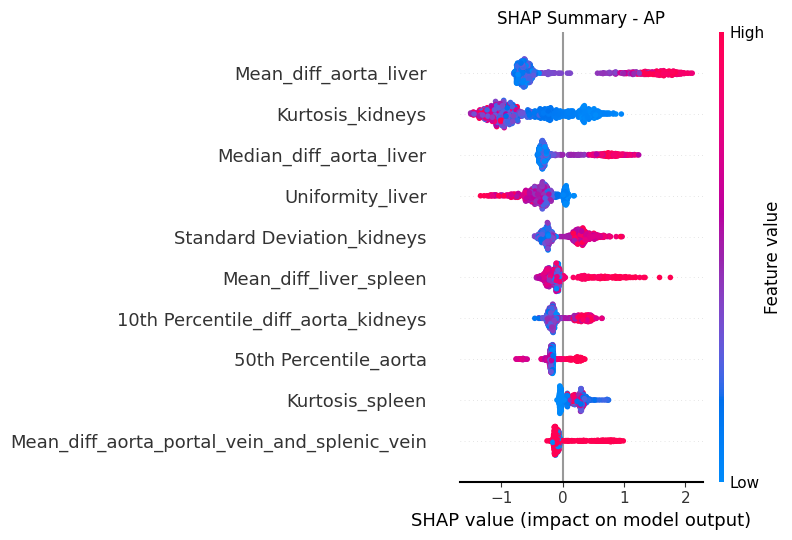

SHAP summary for class: DP


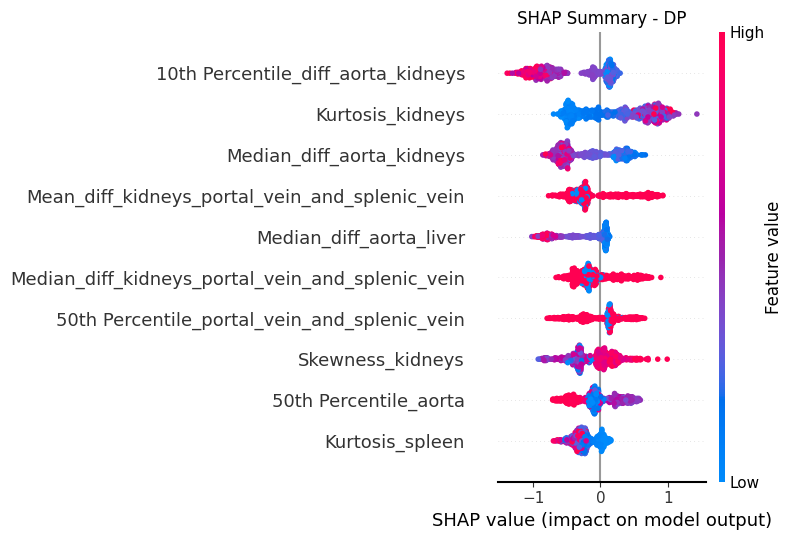

SHAP summary for class: NP


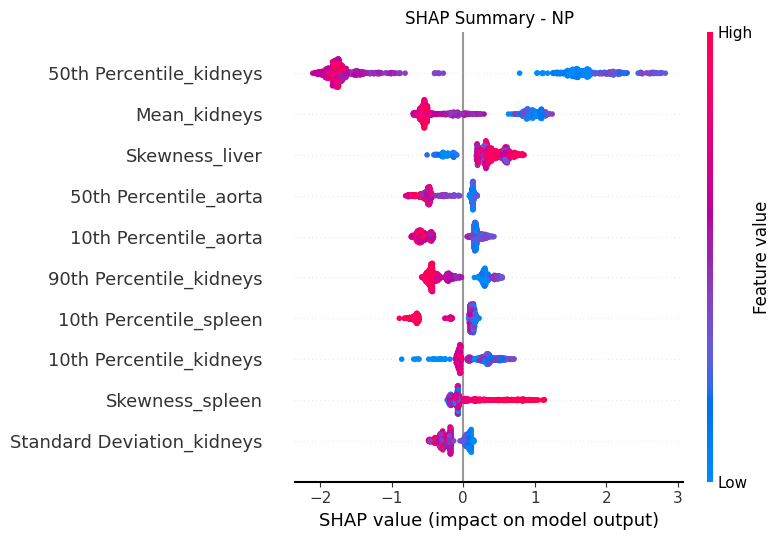

SHAP summary for class: VP


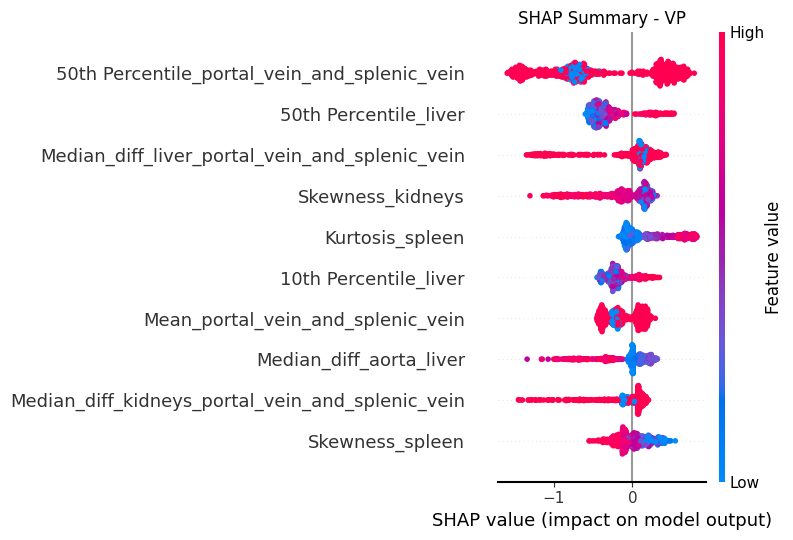

In [48]:
from sklearn.model_selection import StratifiedGroupKFold
from xgboost import XGBClassifier
import numpy as np
import shap
import matplotlib.pyplot as plt

X_internal = df_internal[final_features].copy()
y_internal = df_internal["Phase"].copy()
groups_internal = df_internal["group_id"].copy()

X_external = df_external[final_features].copy()
y_external = df_external["Phase"].copy()
y_internal_enc = label_encoder.transform(y_internal)
y_external_enc = label_encoder.transform(y_external)

class_names = label_encoder.classes_
sgkf_inner = StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=42)

train_dev_idx, internal_test_idx = next(sgkf_inner.split(X_internal, y_internal_enc, groups_internal))
X_train_dev_final = X_internal.iloc[train_dev_idx].reset_index(drop=True)
y_train_dev = y_internal_enc[train_dev_idx]

X_internal_test_final = X_internal.iloc[internal_test_idx].reset_index(drop=True)
y_internal_test = y_internal_enc[internal_test_idx]

X_external_final = X_external.copy()
y_external_enc = y_external_enc
best_xgb_params = {"n_estimators": 1000,"max_depth": 9,"learning_rate": 0.026409871964346382,"subsample": 0.9741551296783776,"colsample_bytree": 0.5603013510634614,"reg_alpha": 1.5764180948248106e-08,"reg_lambda": 3.14338106373698e-07}

class_weights = {0: 1.24986665664131,1: 1.462559787048491,2: 0.48356815253779145,3: 2.420186347362352}

sample_weights = np.array([class_weights[y] for y in y_train_dev])
xgb_model = XGBClassifier(**best_xgb_params,objective="multi:softprob",eval_metric="mlogloss",random_state=42,n_jobs=-1)
xgb_model.fit(X_train_dev_final,y_train_dev,sample_weight=sample_weights)
X_shap = X_external_final.copy()
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

print("X_shap shape:", X_shap.shape)
print("SHAP values type:", type(shap_values))

for class_index, class_name in enumerate(class_names):
    print(f"SHAP summary for class: {class_name}")

    if isinstance(shap_values, list):
        class_shap_values = shap_values[class_index]
    else:
        class_shap_values = shap_values[:, :, class_index]

    plt.figure()
    shap.summary_plot(class_shap_values,X_shap,feature_names=X_shap.columns,show=False, max_display=10)
    plt.title(f"SHAP Summary - {class_name}")
    plt.tight_layout()
    plt.savefig(f"shap_summary_{class_name}_XGBoost_top10.png",dpi=300,bbox_inches="tight")
    plt.show()


ROC AUC (internal, macro OVR): 0.9751030848595738
ROC AUC (external, macro OVR): 0.9330320092047684


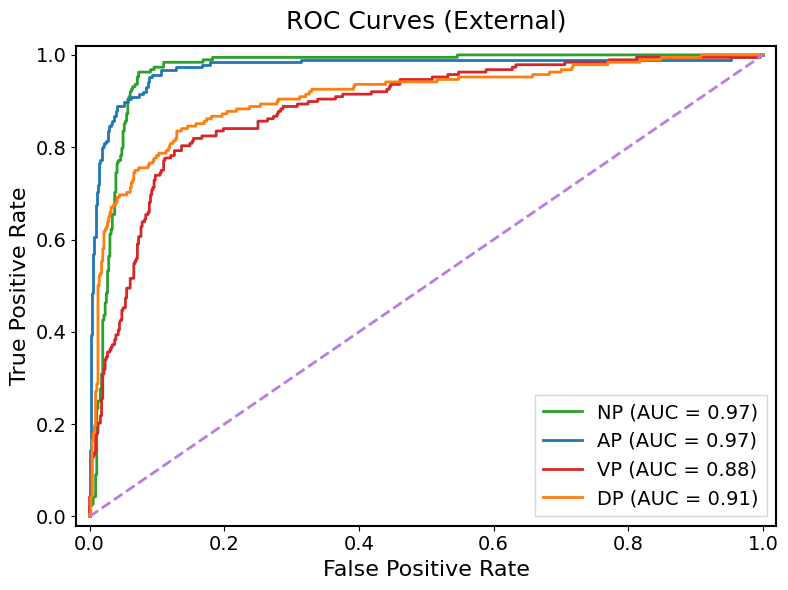

In [29]:
import joblib
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize


best_model = joblib.load("../final_model.pkl")
selected_feature_names = joblib.load("../features.pkl")
label_encoder = joblib.load("../label_encoder.pkl")
class_names = label_encoder.classes_
desired_order = ["NP", "AP", "VP", "DP"]
roc_colors = {"NP": "tab:green","AP": "tab:blue","VP": "tab:red","DP": "tab:orange"}


X_internal = df_internal[selected_feature_names].copy()
y_internal = df_internal["Phase"].copy()
groups_internal = df_internal["group_id"].copy()

X_external = df_external[selected_feature_names].copy()
y_external = df_external["Phase"].copy()

y_internal_enc = label_encoder.transform(y_internal)
y_external_enc = label_encoder.transform(y_external)

sgkf_inner = StratifiedGroupKFold(n_splits=10,shuffle=True,random_state=42)
train_dev_idx, internal_test_idx = next(sgkf_inner.split(X_internal, y_internal_enc, groups_internal))
X_internal_test_final = X_internal.iloc[internal_test_idx].reset_index(drop=True)
y_internal_test = y_internal_enc[internal_test_idx]

X_external_final = X_external.copy()
y_proba_internal = best_model.predict_proba(X_internal_test_final)
y_proba_external = best_model.predict_proba(X_external_final)

model_classes = best_model.classes_
proba_col_by_encoded_label = {encoded_label: np.where(model_classes == encoded_label)[0][0] for encoded_label in model_classes}
all_encoded_classes = np.arange(len(class_names))

y_internal_bin = label_binarize(y_internal_test, classes=all_encoded_classes)
y_external_bin = label_binarize(y_external_enc, classes=all_encoded_classes)

roc_auc_internal = roc_auc_score(y_internal_bin,y_proba_internal,multi_class="ovr",average="macro")
roc_auc_external = roc_auc_score(y_external_bin,y_proba_external,multi_class="ovr",average="macro")
print("ROC AUC (internal, macro OVR):", roc_auc_internal)
print("ROC AUC (external, macro OVR):", roc_auc_external)


def plot_roc_curves(y_binary, y_proba, title, output_stem):
    plt.figure(figsize=(8, 6))

    for phase in desired_order:
        encoded_label = label_encoder.transform([phase])[0]
        bin_col = encoded_label
        proba_col = proba_col_by_encoded_label[encoded_label]

        fpr, tpr, _ = roc_curve(y_binary[:, bin_col],y_proba[:, proba_col])
        phase_auc = auc(fpr, tpr)
        plt.plot(fpr,tpr,color=roc_colors[phase],linewidth=2,label=f"{phase} (AUC = {phase_auc:.2f})")

    plt.plot([0, 1],[0, 1],linestyle="--",color="#b97be5",linewidth=2)
    plt.xlabel("False Positive Rate", fontsize=16)
    plt.ylabel("True Positive Rate", fontsize=16)
    plt.title(title, fontsize=18, pad=12)
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    plt.legend(loc="lower right",fontsize=14,frameon=True,fancybox=False)
    plt.tight_layout()
    plt.savefig(f"{output_stem}.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"{output_stem}.pdf", bbox_inches="tight")
    plt.show()

plot_roc_curves(y_internal_bin,y_proba_internal,"ROC Curves (Internal)","roc_auc_internal_XGBoost_styled")
plot_roc_curves(y_external_bin,y_proba_external,"ROC Curves (External)","roc_auc_external_XGBoost_styled")
